In [1]:
import xarray as xr

ds = xr.open_dataset("chirps-v3.0.2026.01.days_p05.nc")
print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 31, latitude: 2400, longitude: 7200)
Coordinates:
  * time       (time) datetime64[ns] 248B 2026-01-01 2026-01-02 ... 2026-01-31
  * latitude   (latitude) float32 10kB -59.97 -59.92 -59.88 ... 59.92 59.97
  * longitude  (longitude) float32 29kB -180.0 -179.9 -179.9 ... 179.9 180.0
Data variables:
    precip     (time, latitude, longitude) float32 2GB ...
Attributes: (12/14)
    Conventions:       CF-1.6
    title:             CHIRPS Version 3.0
    history:           created by Climate Hazards Center
    version:           Version 3.0
    data_created:      2026-02-19
    creator_name:      Pete Peterson
    ...                ...
    documentation:     http://pubs.usgs.gov/ds/832/
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    acknowledgements:  The Climate Hazards Center InfraRed Precipitation with...
    ftp_url:           ftp://chg-ftpout.geog.ucsb.edu/pub/chg/products/CHIRPS...
    website:     

In [2]:
precip = ds["precip"]   # change to actual variable name
print(precip)

<xarray.DataArray 'precip' (time: 31, latitude: 2400, longitude: 7200)> Size: 2GB
[535680000 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 248B 2026-01-01 2026-01-02 ... 2026-01-31
  * latitude   (latitude) float32 10kB -59.97 -59.92 -59.88 ... 59.92 59.97
  * longitude  (longitude) float32 29kB -180.0 -179.9 -179.9 ... 179.9 180.0
Attributes:
    units:               mm/day
    standard_name:       convective precipitation rate
    long_name:           Climate Hazards center InfraRed Precipitation with S...
    time_step:           day
    geostatial_lat_min:  -60
    geostatial_lat_max:  60
    geostatial_lon_min:  -180.0
    geostatial_lon_max:  180.0


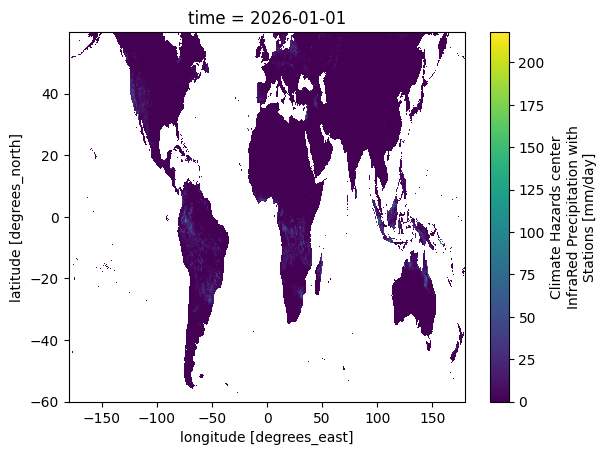

In [3]:
precip.isel(time=0).plot()

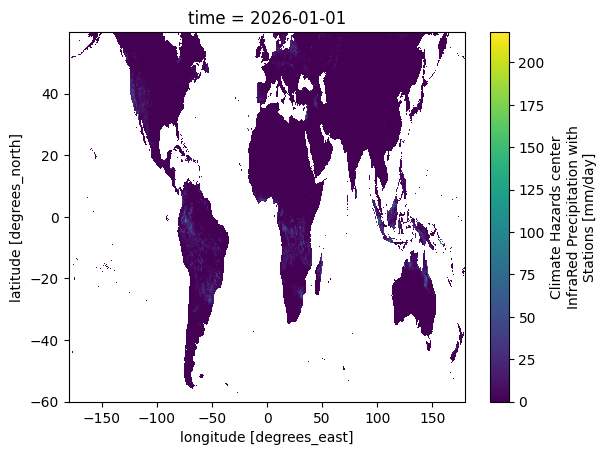

In [4]:
precip.sel(time="2026-01-01").plot()

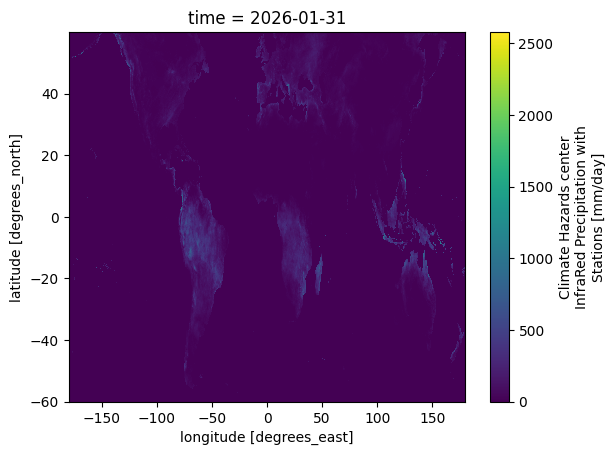

In [6]:
monthly = precip.resample(time="1ME").sum()
monthly.isel(time=0).plot()

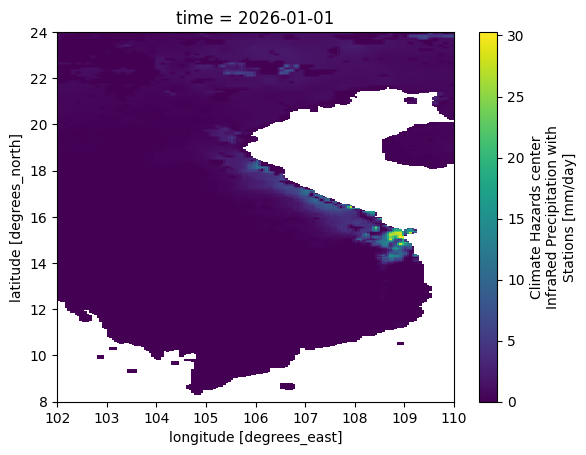

In [10]:
vietnam = precip.sel(
    latitude=slice(8, 24),
    longitude=slice(102, 110)
)

vietnam.isel(time=0).plot()

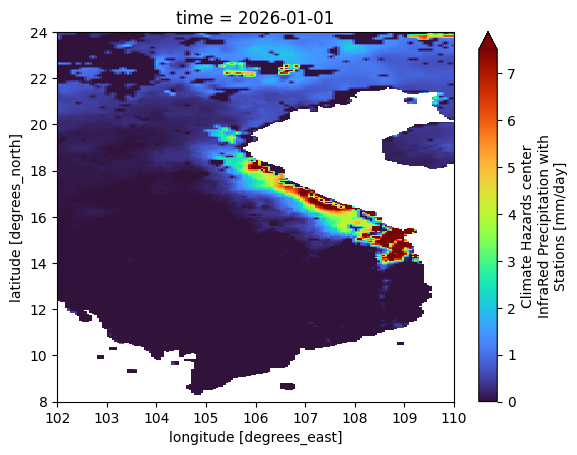

In [11]:
import numpy as np

day0 = vietnam.isel(time=0)

vmax = np.nanpercentile(day0, 99)

day0.plot(
    cmap="turbo",
    vmin=0,
    vmax=vmax
)

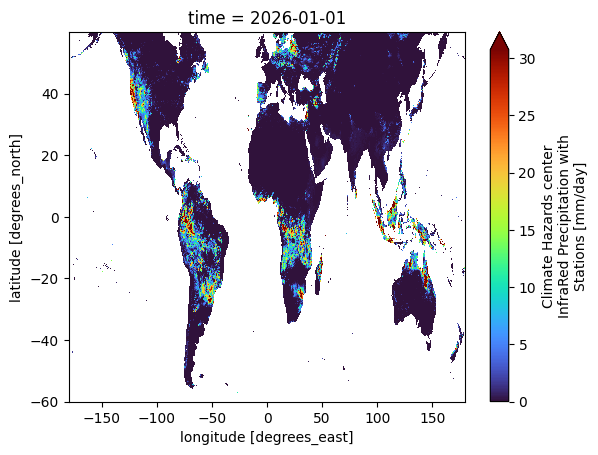

In [12]:
import numpy as np

day0 = precip.isel(time=0)

vmax = np.nanpercentile(day0, 99)

day0.plot(
    cmap="turbo",
    vmin=0,
    vmax=vmax
)

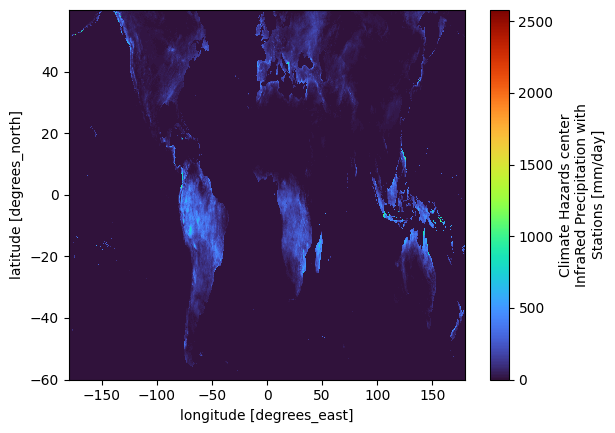

In [21]:
monthly_total = precip.sum(dim="time")

monthly_total.plot(cmap="turbo")

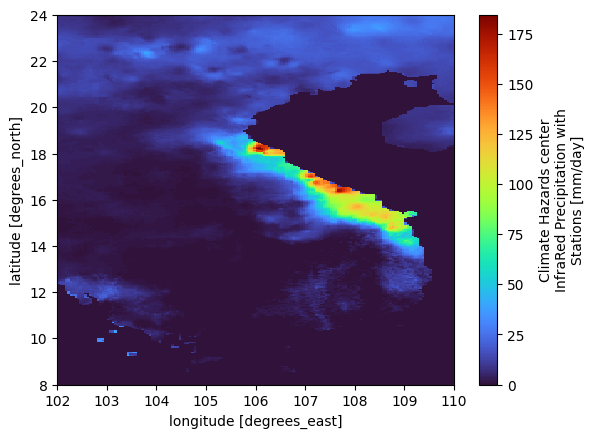

In [14]:
monthly_total = precip.sum(dim="time")

vietnam_month = monthly_total.sel(
    latitude=slice(8, 24),
    longitude=slice(102, 110)
)

vietnam_month.plot(cmap="turbo")

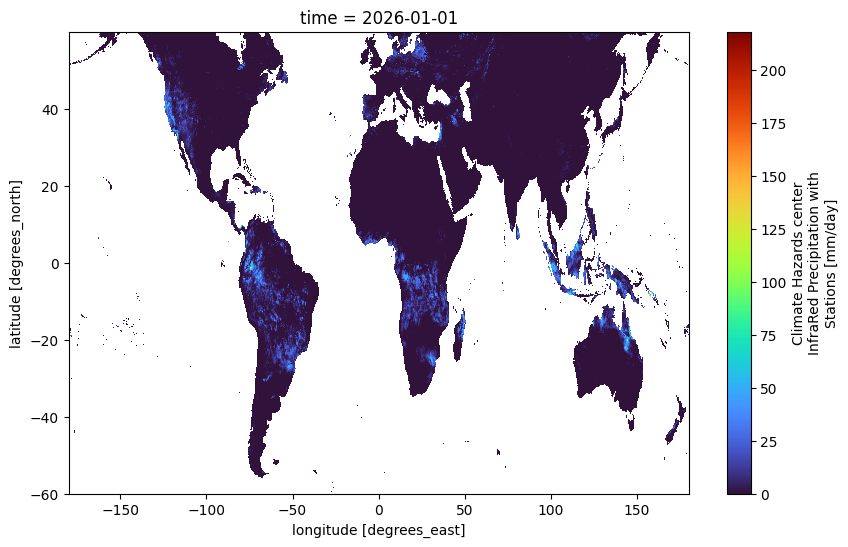

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))   # width, height in inches

precip.isel(time=0).plot(cmap="turbo")

plt.show()

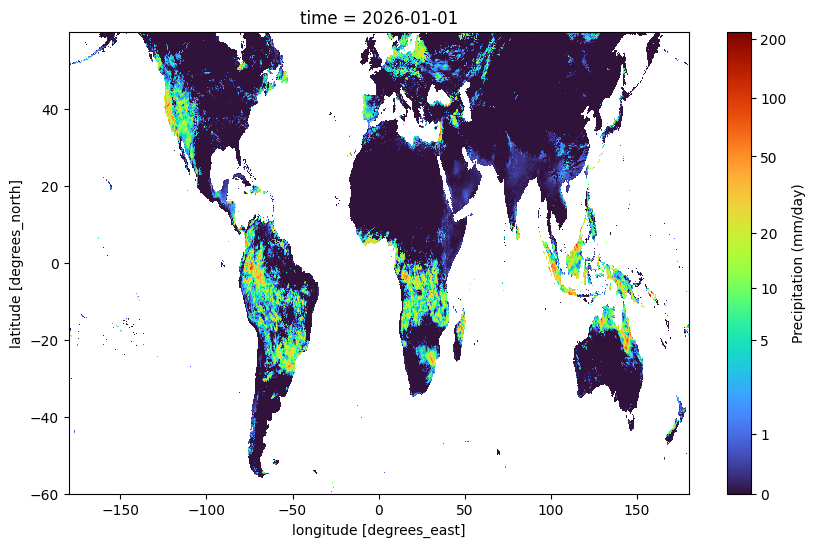

In [46]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

day0 = precip.isel(time=0)
log_rain = np.log1p(day0)

mappable = log_rain.plot(cmap="turbo")
cbar = mappable.colorbar

# Choose nice rounded rainfall values (mm)
nice_mm = np.array([0, 1, 5, 10, 20, 50, 100, 200])

# Convert them to log1p scale (because your image is log1p)
log_ticks = np.log1p(nice_mm)

# Apply ticks
cbar.set_ticks(log_ticks)
cbar.set_ticklabels([str(v) for v in nice_mm])
cbar.set_label("Precipitation (mm/day)")

plt.show()